In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('data.csv')

In [7]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [8]:
df.shape

(381109, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
    print(col ,df[col].unique())

id [     1      2      3 ... 381107 381108 381109]
Gender ['Male' 'Female']
Age [44 76 47 21 29 24 23 56 32 41 71 37 25 42 60 65 49 34 51 26 57 79 48 45
 72 30 54 27 38 22 78 20 39 62 58 59 63 50 67 77 28 69 52 31 33 43 36 53
 70 46 55 40 61 75 64 35 66 68 74 73 84 83 81 80 82 85]
Driving_License [1 0]
Region_Code [28.  3. 11. 41. 33.  6. 35. 50. 15. 45.  8. 36. 30. 26. 16. 47. 48. 19.
 39. 23. 37.  5. 17.  2.  7. 29. 46. 27. 25. 13. 18. 20. 49. 22. 44.  0.
  9. 31. 12. 34. 21. 10. 14. 38. 24. 40. 43. 32.  4. 51. 42.  1. 52.]
Previously_Insured [0 1]
Vehicle_Age ['> 2 Years' '1-2 Year' '< 1 Year']
Vehicle_Damage ['Yes' 'No']
Annual_Premium [ 40454.  33536.  38294. ...  20706. 101664.  69845.]
Policy_Sales_Channel [ 26. 152. 160. 124.  14.  13.  30. 156. 163. 157. 122.  19.  22.  15.
 154.  16.  52. 155.  11. 151. 125.  25.  61.   1.  86.  31. 150.  23.
  60.  21. 121.   3. 139.  12.  29.  55.   7.  47. 127. 153.  78. 158.
  89.  32.   8.  10. 120.  65.   4.  42.  83. 136.  24.  18.  56

In [12]:
num_cols = ['Age','Annual_Premium','Vintage']
cat_cols = ['Gender','Driving_License','Region_Code','Previously_Insured','Vehicle_Age','Vehicle_Damage','Policy_Sales_Channel','Response']

In [13]:
# Understanding descriptive statistics of numerical columns
df[num_cols].describe()

,Age,Annual_Premium,Vintage
count,381109.000000,381109.000000,381109.000000
mean,38.822584,30564.389581,154.347397
std,15.511611,17213.155057,83.671304
min,20.000000,2630.000000,10.000000
25%,25.000000,24405.000000,82.000000
50%,36.000000,31669.000000,154.000000
75%,49.000000,39400.000000,227.000000
max,85.000000,540165.000000,299.000000


### Numerical columns Univariate analysis
*Inference*
- Age and Annual premium is positively skewed (right) 
- Vintage is uniformaly distributed
- Possible outliers in Annual premium 

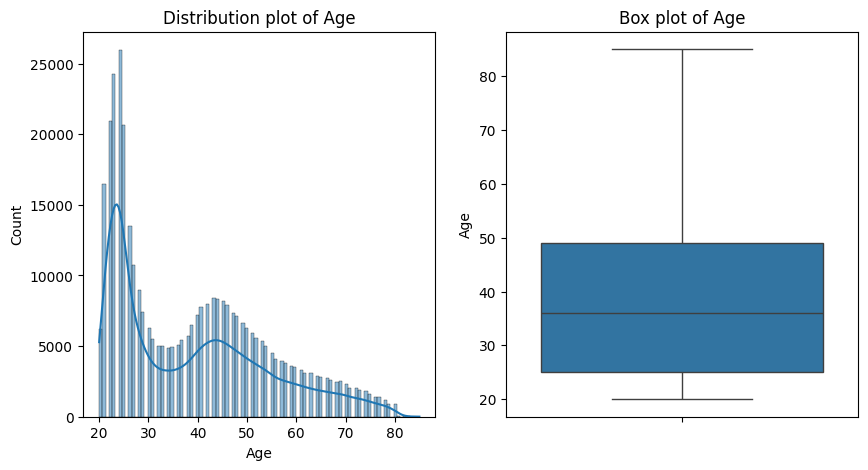

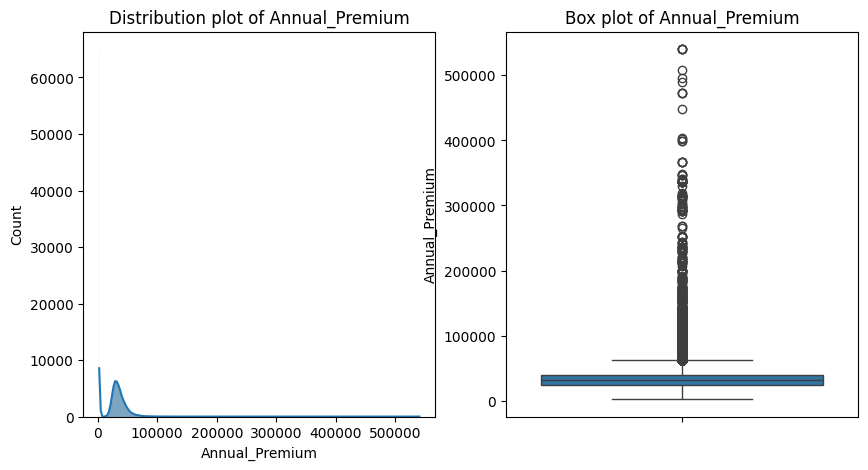

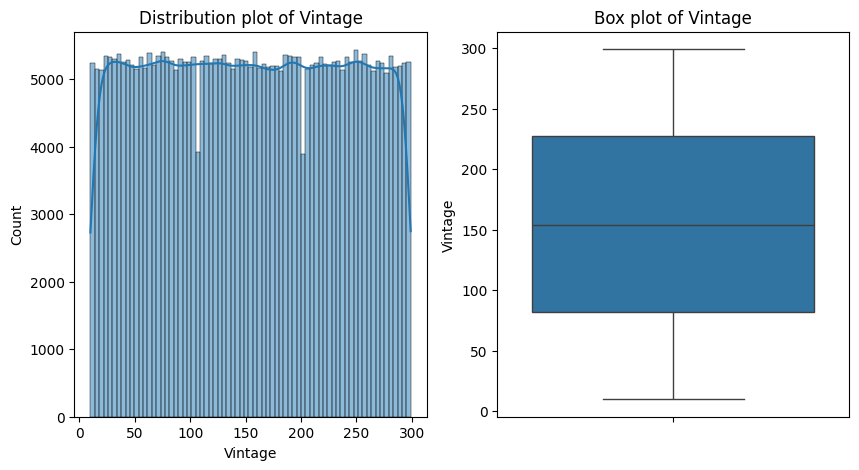

In [14]:
for col in num_cols:

    fig, axes = plt.subplots(1,2,figsize = (10,5))
    
    sns.histplot(df[col], kde=True, ax = axes[0])
    axes[0].set_title(f"Distribution plot of {col}")

    sns.boxplot(df[col], ax = axes[1])
    axes[1].set_title(f"Box plot of {col}")

### Categorical columns Univariate analysis

*Inference*
- 99.8% Almost everyone has license
- 46% were previously insured
- more than half of them are male
- very few vehicle had more than 2 years of age
- half of them had damaged vehicle
- only 12% responded positively for insurance

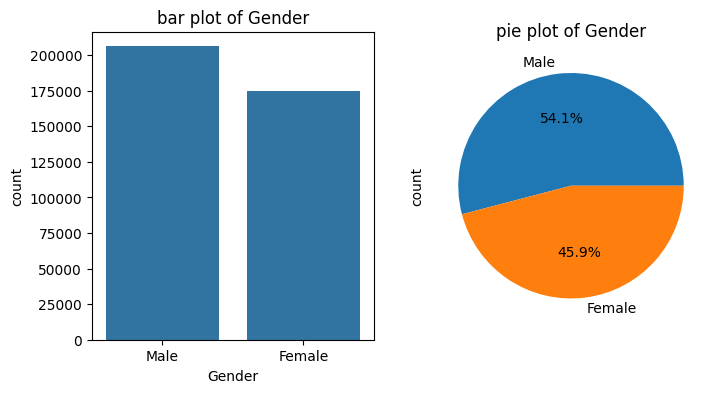

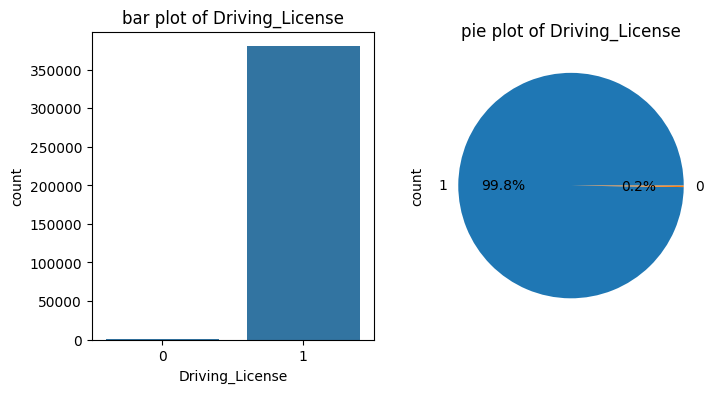

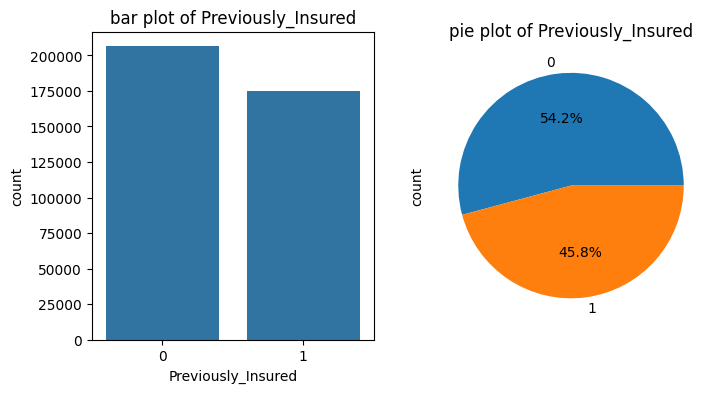

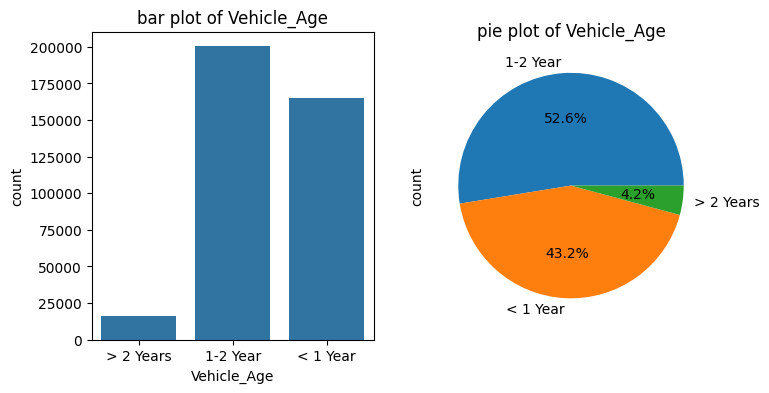

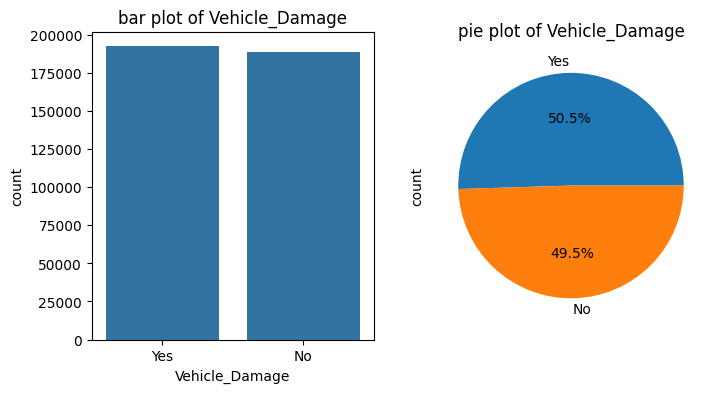

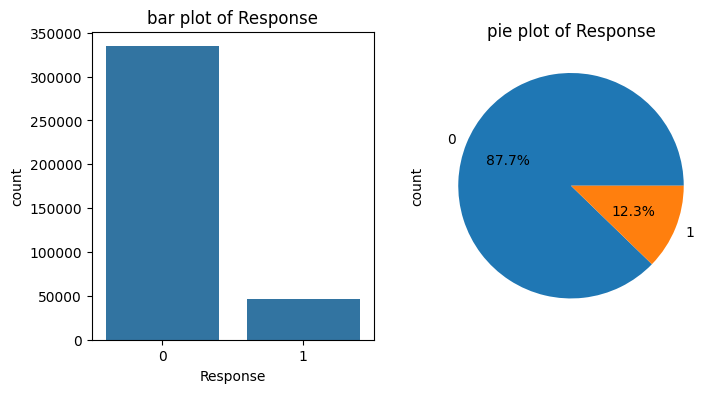

In [15]:
for col in cat_cols:
    if col not in ['Region_Code','Policy_Sales_Channel']:
        fig, axes = plt.subplots(1,2,figsize = (8,4))

        sns.countplot(x = col, data = df, ax = axes[0])
        axes[0].set_title(f"bar plot of {col}")

        df[col].value_counts().plot(kind = 'pie', autopct='%1.1f%%', ax = axes[1])
        axes[1].set_title(f"pie plot of {col}")

In [16]:
# for bivariate analysis between 
df[['Age','Annual_Premium','Vintage','Previously_Insured', 'Response']].corr()['Response']

Age                   0.111147
Annual_Premium        0.022575
Vintage              -0.001050
Previously_Insured   -0.341170
Response              1.000000
Name: Response, dtype: float64

## Bivariate analysis

### performing bivariate analysis between cat-cat data
**Inference**
- Male has slightly more positive reponse to buy insurance than Female
- Almost everyone who had license, 12% of them bought an insurance
- None of previously insured person bought insurance
- Vehicle_age above 2 years had higher chance of buying insurance
- None of whose vehicle is not damaged has bought insurance

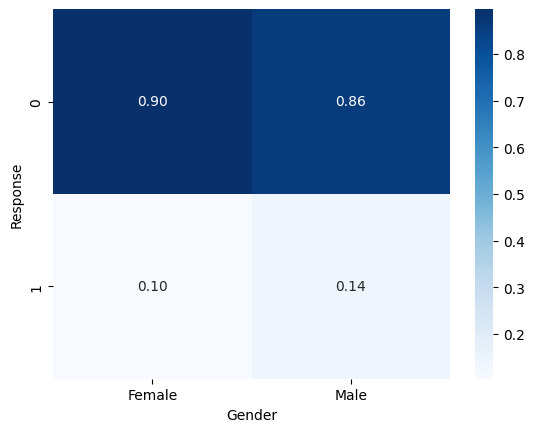

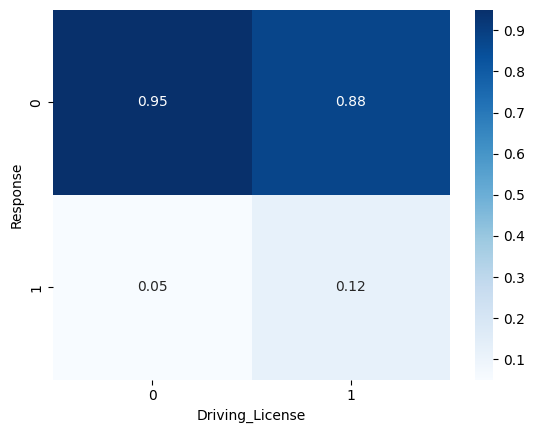

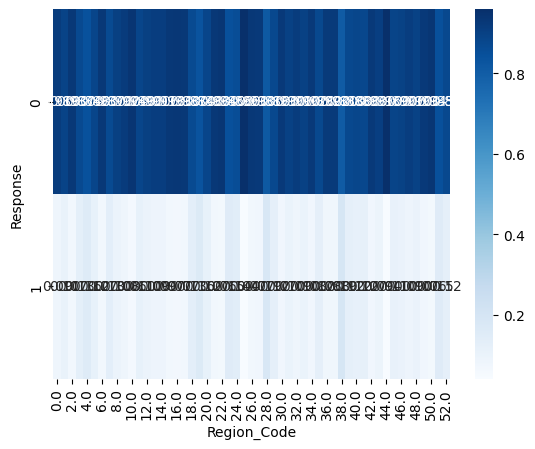

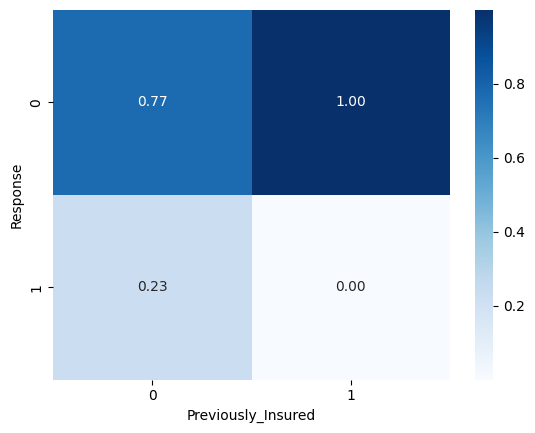

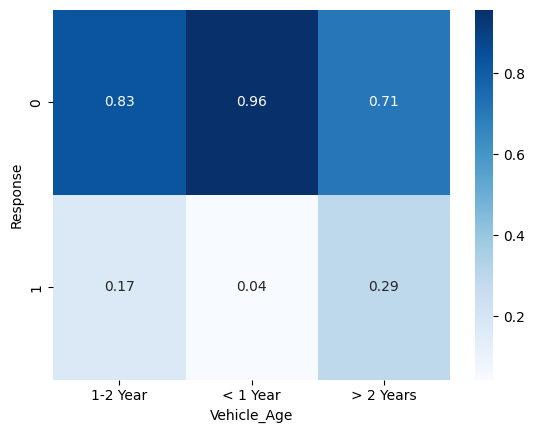

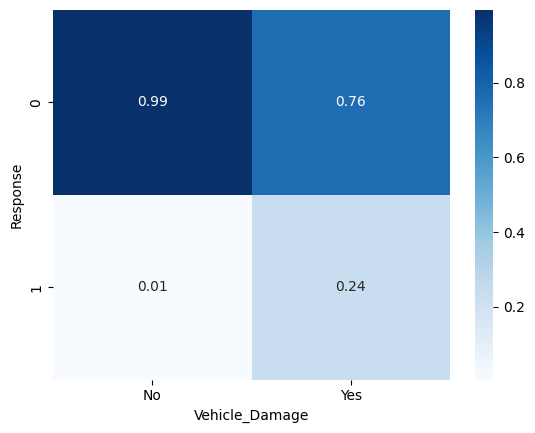

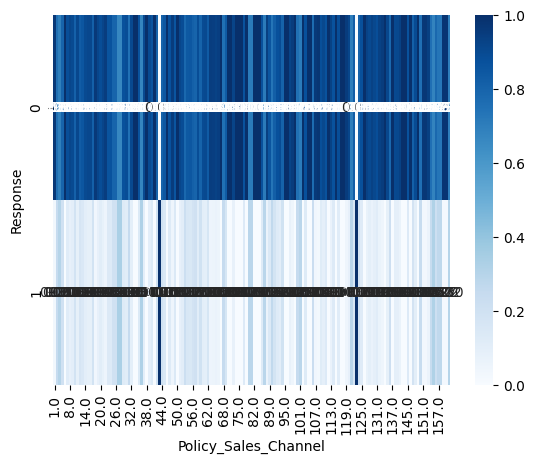

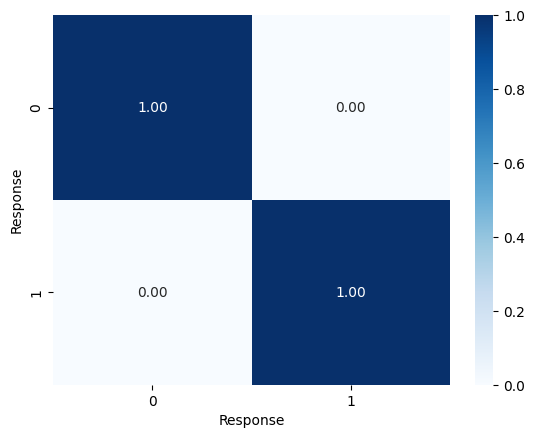

In [17]:

for col in cat_cols:
    sns.heatmap(pd.crosstab(df['Response'],df[col], normalize='columns'),annot = True,fmt = ".2f",cmap = "Blues")
    plt.show()
    print('\n')
    

### Performing bivariate analysis using cat-numerical columns
**Inference**
- Age group between 30 to 60 responded more positively to buy the insurance

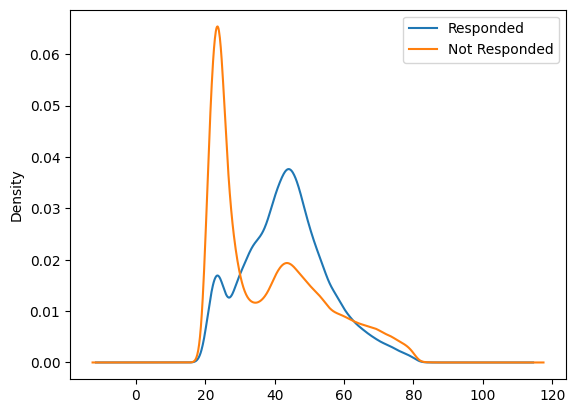

In [18]:
df[df['Response'] == 1]['Age'].plot(kind= 'kde',label = 'Responded')

df[df['Response'] == 0]['Age'].plot(kind= 'kde',label = 'Not Responded')

plt.legend()
plt.show()


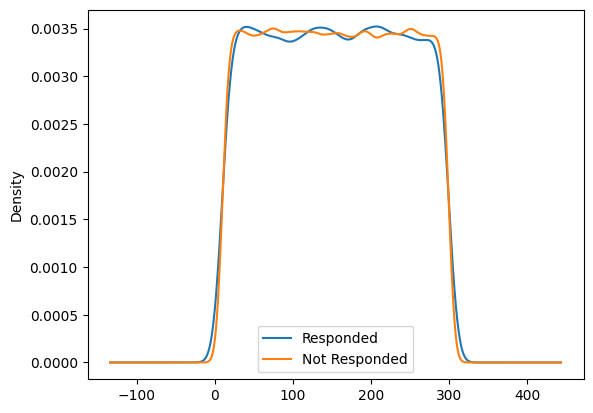

In [19]:
df[df['Response'] == 1]['Vintage'].plot(kind= 'kde',label = 'Responded')

df[df['Response'] == 0]['Vintage'].plot(kind= 'kde',label = 'Not Responded')

plt.legend()
plt.show()

## Feature Engineering

In [20]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [21]:
df1 = df.drop(labels='id', axis = 1)

<Axes: xlabel='Region_Code'>

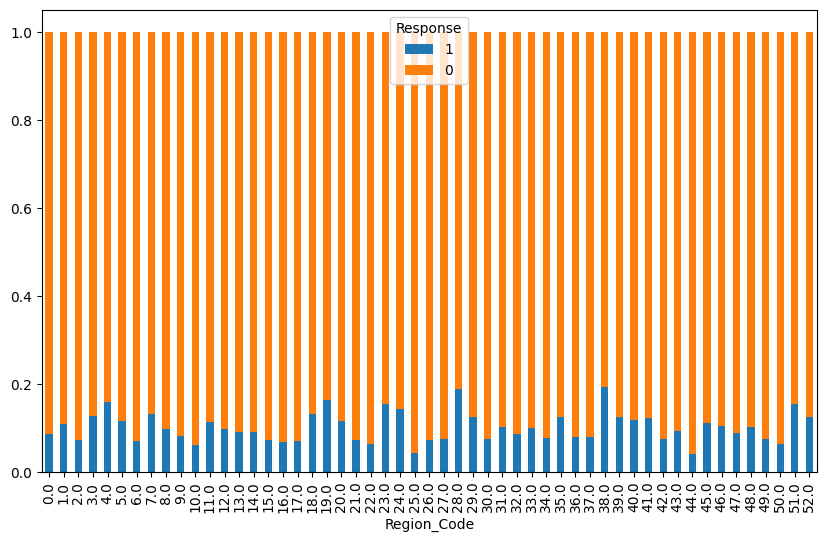

In [22]:
# exploring region_code, policy_sales_channel
ct = pd.crosstab(df['Region_Code'],df['Response'],  normalize='index')
ct = ct[[1,0]]
ct.plot(kind='bar', stacked=True, figsize=(10,6))

<Axes: xlabel='Policy_Sales_Channel'>

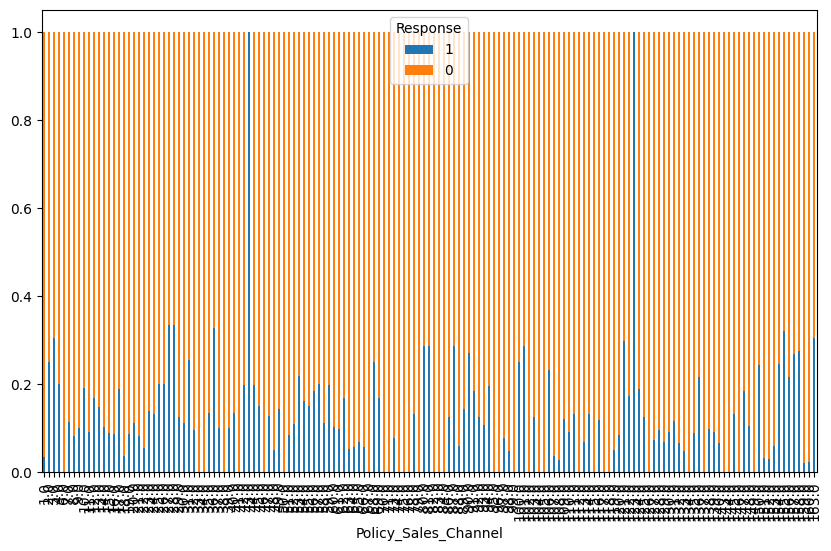

In [23]:
ct = pd.crosstab(df['Policy_Sales_Channel'],df['Response'],  normalize='index')
ct = ct[[1,0]]
ct.plot(kind='bar', stacked=True, figsize=(10,6))

### Feature Engineering

In [24]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [25]:
std_cols = ['Age','Vintage']
min_max_cols = ['Annual_Premium']
target_encode_cols = ['Policy_Sales_Channel', 'Region_Code']
ohe_cols = ['Gender','Vehicle_Age', 'Vehicle_Damage']

In [26]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


In [27]:
std_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
     ("scaler",StandardScaler())
     
])
mm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",MinMaxScaler())
])
target_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("target_enc",TargetEncoder(smooth='auto'))
])
ohe_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("ohe",OneHotEncoder(drop = 'first',handle_unknown='ignore'))
])

In [28]:
preprocessor = ColumnTransformer(
    transformers = [
        ("std",std_pipeline,std_cols),
        ("mm",mm_pipeline,min_max_cols),
        ("te",target_pipeline,target_encode_cols),
        ("ohe",ohe_pipeline,ohe_cols)
    ],
    remainder='passthrough'
)

In [29]:
X = df1.drop(labels='Response', axis=1)
y = df1['Response']

In [30]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [31]:
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
332803,Female,39,1,15.0,0,1-2 Year,Yes,52906.0,55.0,227
116248,Male,38,1,11.0,0,1-2 Year,Yes,23038.0,26.0,29
255005,Male,22,1,30.0,1,< 1 Year,No,45318.0,152.0,166
317474,Female,23,1,41.0,1,< 1 Year,No,29132.0,151.0,277
344212,Male,56,1,48.0,0,> 2 Years,Yes,2630.0,154.0,155


In [32]:
X_train1 = pd.DataFrame(preprocessor.fit_transform(X_train, y_train),columns=preprocessor.get_feature_names_out())

In [33]:
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
332803,Female,39,1,15.0,0,1-2 Year,Yes,52906.0,55.0,227
116248,Male,38,1,11.0,0,1-2 Year,Yes,23038.0,26.0,29
255005,Male,22,1,30.0,1,< 1 Year,No,45318.0,152.0,166
317474,Female,23,1,41.0,1,< 1 Year,No,29132.0,151.0,277
344212,Male,56,1,48.0,0,> 2 Years,Yes,2630.0,154.0,155


In [34]:
X_train.rename(columns={'ohe__Vehicle_Age_< 1 Year' : 'ohe_Vehicle_Age_lt_1_Year','ohe__Vehicle_Age_> 2 Years' : 'ohe_Vehicle_Age_mt_2_Year' }, inplace=True)

In [35]:
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
332803,Female,39,1,15.0,0,1-2 Year,Yes,52906.0,55.0,227
116248,Male,38,1,11.0,0,1-2 Year,Yes,23038.0,26.0,29
255005,Male,22,1,30.0,1,< 1 Year,No,45318.0,152.0,166
317474,Female,23,1,41.0,1,< 1 Year,No,29132.0,151.0,277
344212,Male,56,1,48.0,0,> 2 Years,Yes,2630.0,154.0,155


In [46]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
import pandas as pd

In [47]:
class FeatureNamesCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.feature_names_out_ = None

    def fit(self, X, y=None):
        self.preprocessor.fit(X,y)
        raw_names = self.preprocessor.get_feature_names_out()
        #cleaner names
        clean_names =  [re.sub(r'[^0-9a-zA-Z_]+','_',name) for name in raw_names]
        self.feature_names_out_ = clean_names
        return self
    
    def transform(self, X):
        Xt = self.preprocessor.transform(X)
        return pd.DataFrame(Xt, columns=self.feature_names_out_)
    
    def get_features_names_out(self):
        return self.feature_names_out_



In [48]:
clean_preprocessor = FeatureNamesCleaner(preprocessor=preprocessor)

In [49]:
X_train = pd.DataFrame(clean_preprocessor.fit_transform(X_train, y_train),columns=clean_preprocessor.get_features_names_out())

In [ ]:
X_train


,std__Age,std__Vintage,mm__Annual_Premium,te__Policy_Sales_Channel,te__Region_Code,ohe__Gender_Male,ohe__Vehicle_Age__1_Year,ohe__Vehicle_Age__2_Years,ohe__Vehicle_Damage_Yes,remainder__Driving_License,remainder__Previously_Insured
0,0.010601,0.869505,0.093531,0.158528,0.070154,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.053875,-1.497719,0.037966,0.197695,0.109797,1.0,0.0,0.0,1.0,1.0,0.0
2,-1.085502,0.140209,0.079414,0.028598,0.074308,1.0,1.0,0.0,0.0,1.0,1.0
3,-1.021025,1.467289,0.049303,0.032972,0.122946,0.0,1.0,0.0,0.0,1.0,1.0
4,1.106704,0.008696,0.000000,0.243150,0.100983,1.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
304882,-0.956548,1.586846,0.037105,0.028598,0.075988,0.0,1.0,0.0,0.0,1.0,1.0
304883,1.106704,1.718359,0.071915,0.187676,0.123209,1.0,0.0,0.0,1.0,1.0,0.0
304884,-1.085502,-0.935802,0.030188,0.028598,0.074697,0.0,1.0,0.0,1.0,1.0,0.0
304885,0.332984,-1.234694,0.000000,0.216397,0.084279,1.0,0.0,0.0,1.0,1.0,1.0


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [37]:
clfs = {
    'lr': LogisticRegression(),
    'dtc': DecisionTreeClassifier(),
    'rfc': RandomForestClassifier(),
    'gbc': GradientBoostingClassifier(),
    'xgb': XGBClassifier()
}

In [38]:
from pandas import DataFrame
from sklearn.metrics import accuracy_score, precision_score, recall_score

def model_trainer(clfs,X_train,X_test, y_train, y_test ):
    """
    Traines the data with the given model 
    """
    clfs.fit(X_train, y_train)
    y_pred = clfs.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    return accuracy, precision, recall
    


In [39]:
X_test1 = pd.DataFrame(preprocessor.transform(X_test),columns=preprocessor.get_feature_names_out())

In [40]:
X_test.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
200222,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72
49766,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102
172201,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90
160713,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268
53272,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265


In [41]:
X_test.rename(columns={'ohe__Vehicle_Age_< 1 Year' : 'ohe_Vehicle_Age_lt_1_Year','ohe__Vehicle_Age_> 2 Years' : 'ohe_Vehicle_Age_mt_2_Year' }, inplace=True)

In [42]:
for name, model in clfs.items():

    accuracy, precision, recall = model_trainer(model, X_train, X_test, y_train, y_test)

    print(f"Performance of model:{name}")
    print("Accuracy", accuracy)
    print("Precision", precision)
    print("Recall", recall)
    print("==================")
    

ValueError: could not convert string to float: 'Female'